Finished: K_vs_T.png, K_vs_time_L200.png, K_vs_time_L400.png, K_vs_time_L600.png


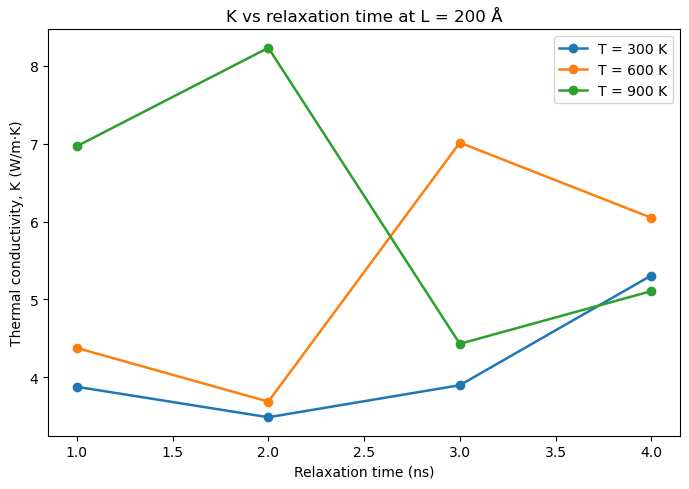

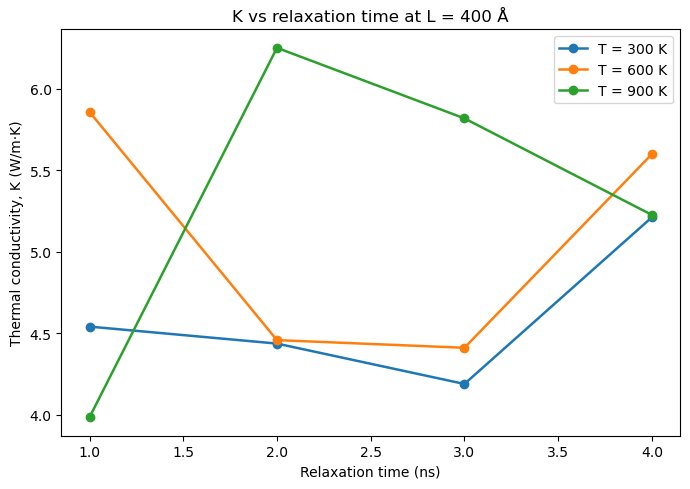

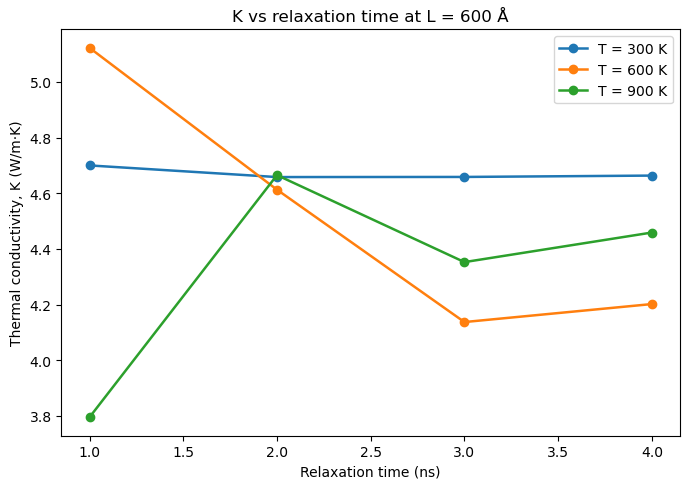

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read Excel
file_path = "wrapup.xlsx"
sheet_name = "main"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# ---------------------------
# Figure 1: K vs T at 4 ns
# ---------------------------
df_4ns = df[df["Time(ns)"] == 4].copy()

plt.figure(figsize=(7,5))
for size in sorted(df_4ns["Size"].unique()):
    sub = df_4ns[df_4ns["Size"] == size].sort_values("Temp")
    plt.plot(
        sub["Temp"],
        sub["K_last4avg (W/m·K)"],
        marker="o",
        linewidth=1.8,
        label=f"L = {size} Å"
    )

plt.xlabel("Temperature (K)")
plt.ylabel("Thermal conductivity, K (W/m·K)")
plt.title("K vs T for different system sizes")
plt.legend()
plt.tight_layout()
plt.savefig("K_vs_T.png", dpi=300)
plt.close()

# ------------------------------------------
# Figure 2a/2b/2c: K vs relaxation time
# ------------------------------------------
for size in sorted(df["Size"].unique()):
    sub_size = df[df["Size"] == size].copy()

    plt.figure(figsize=(7,5))
    for temp in sorted(sub_size["Temp"].unique()):
        sub = sub_size[sub_size["Temp"] == temp].sort_values("Time(ns)")
        plt.plot(
            sub["Time(ns)"],
            sub["K_last4avg (W/m·K)"],
            marker="o",
            linewidth=1.8,
            label=f"T = {temp} K"
        )

    plt.xlabel("Relaxation time (ns)")
    plt.ylabel("Thermal conductivity, K (W/m·K)")
    plt.title(f"K vs relaxation time at L = {size} Å")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"K_vs_time_L{size}.png", dpi=300)
    #plt.close()

print("Finished: K_vs_T.png, K_vs_time_L200.png, K_vs_time_L400.png, K_vs_time_L600.png")